<a href="https://colab.research.google.com/github/Handinoasa/PCVK_2026/blob/main/Week5_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#E-1 Percobaan Histogram

NAMA   : Handino Asa Galih
NIM    : 2144107020237 | N = 237
bins   : 16
clip   : 2.0
tile   : 3
L      : 2
WAKTU  : 2026-09-29 17:45:34 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : f3edb7020c427a92


Text(0.5, 1.0, '2144107020237 - CLAHE clip 2.0')

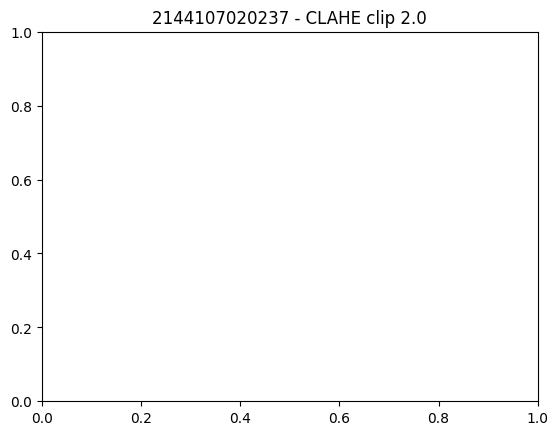

In [ ]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Handino Asa Galih'
NIM  = '2144107020237'          # ganti dengan NIM Anda
N     = int(NIM[-3:])
PARAM = {
'bins' : 2 ** ((N % 4) + 3),
'clip' : round(1.0 + (N % 5) * 0.5, 1),
'tile' : (N % 4) + 2,
'L'    : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
  print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

plt.title(NIM + ' - CLAHE clip ' + str(PARAM['clip']))

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
import math
import os
import glob

3. Membuat histogram citra berdasarkan flowchart di bawah ini. Tahap 1 gunakan citra
contoh lena.jpg dan cocokkan keluarannya dengan gambar contoh pada modul;
setelah cocok, tahap 2 ulangi dengan citra KTM1b.jpg milik Anda sendiri.

<BarContainer object of 256 artists>

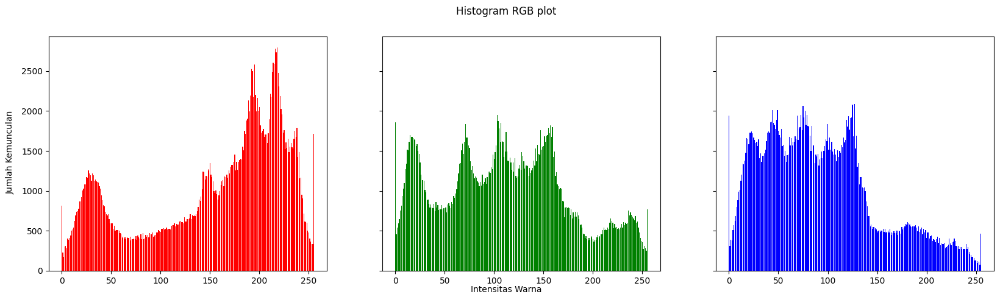

In [ ]:
# TAHAP 1
# membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)

names = np.arange(256)

red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

fig.suptitle('Histogram RGB plot')

fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

<BarContainer object of 256 artists>

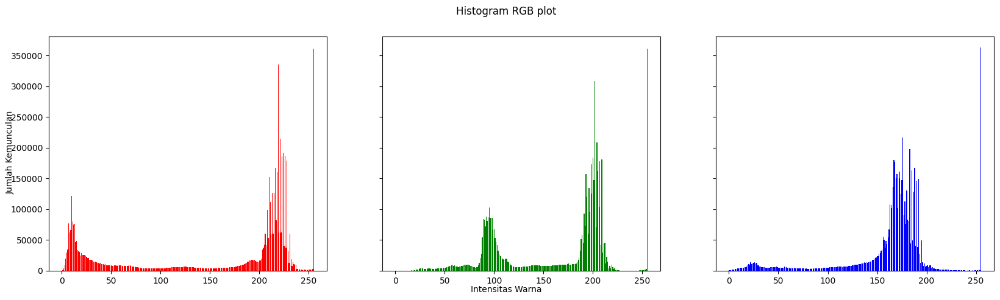

In [ ]:
# TAHAP 2
img = cv.imread('/content/drive/MyDrive/Images/KTM/tilKTM1b.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)

names = np.arange(256)

red = [0] * 256
green = [0] * 256
blue = [0] * 256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

fig.suptitle('Histogram RGB plot')

fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

### PERTANYAAN PRAKTIKUM E1

1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

NIM = '244107020237'

CONTOH = '/content/drive/MyDrive/Images/KTM'

print('NIM:', NIM)
print('Folder:', CONTOH)

NIM: 244107020237
Folder: /content/drive/MyDrive/Images/KTM


In [ ]:
def histogram_manual(gray):
    h = np.zeros(256, dtype=np.int64)

    for y in range(gray.shape[0]):
        for x in range(gray.shape[1]):
            h[gray[y, x]] += 1

    return h

In [ ]:
def bandingkan_histogram(path, nama_citra):

    # Membaca citra grayscale
    gray = cv.imread(path, cv.IMREAD_GRAYSCALE)

    if gray is None:
        print('ERROR: Citra tidak ditemukan!')
        print('Lokasi:', path)
        return

    hist_manual = histogram_manual(gray)

    hist_numpy, bins = np.histogram(
        gray,
        bins=256,
        range=(0, 256)
    )

    hist_cv = cv.calcHist(
        [gray],
        [0],
        None,
        [256],
        [0, 256]
    )

    hist_cv = hist_cv.flatten()

    selisih_manual_numpy = np.max(
        np.abs(hist_manual - hist_numpy)
    )

    selisih_manual_cv = np.max(
        np.abs(hist_manual - hist_cv)
    )

    selisih_numpy_cv = np.max(
        np.abs(hist_numpy - hist_cv)
    )

    print('=' * 60)
    print('HASIL PERBANDINGAN HISTOGRAM')
    print('=' * 60)

    print('Nama citra:', nama_citra)
    print('Ukuran citra:', gray.shape)
    print()

    print(
        'Selisih maksimum Manual vs NumPy :',
        selisih_manual_numpy
    )

    print(
        'Selisih maksimum Manual vs cv.calcHist :',
        selisih_manual_cv
    )

    print(
        'Selisih maksimum NumPy vs cv.calcHist :',
        selisih_numpy_cv
    )

    print()

    selisih_maksimum = max(
        selisih_manual_numpy,
        selisih_manual_cv,
        selisih_numpy_cv
    )

    print(
        'SELISIH MAKSIMUM KETIGA METODE:',
        selisih_maksimum
    )

    if selisih_maksimum == 0:
        print('✓ Ketiga histogram SAMA PERSIS')
    else:
        print('✗ Terdapat perbedaan')

    print('=' * 60)

    intensitas = np.arange(256)

    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(intensitas, hist_manual)
    plt.title(NIM + ' - Histogram Manual')
    plt.xlabel('Intensitas')
    plt.ylabel('Jumlah Pixel')
    plt.xlim(0, 255)

    plt.subplot(1, 3, 2)
    plt.plot(intensitas, hist_numpy)
    plt.title(NIM + ' - Histogram NumPy')
    plt.xlabel('Intensitas')
    plt.ylabel('Jumlah Pixel')
    plt.xlim(0, 255)

    plt.subplot(1, 3, 3)
    plt.plot(intensitas, hist_cv)
    plt.title(NIM + ' - Histogram cv.calcHist')
    plt.xlabel('Intensitas')
    plt.ylabel('Jumlah Pixel')
    plt.xlim(0, 255)

    plt.suptitle(
        NIM + ' - Perbandingan Histogram ' + nama_citra
    )

    plt.tight_layout()
    plt.show()

    return hist_manual, hist_numpy, hist_cv

HASIL PERBANDINGAN HISTOGRAM
Nama citra: lena.jpg
Ukuran citra: (512, 512)

Selisih maksimum Manual vs NumPy : 0
Selisih maksimum Manual vs cv.calcHist : 0.0
Selisih maksimum NumPy vs cv.calcHist : 0.0

SELISIH MAKSIMUM KETIGA METODE: 0
✓ Ketiga histogram SAMA PERSIS


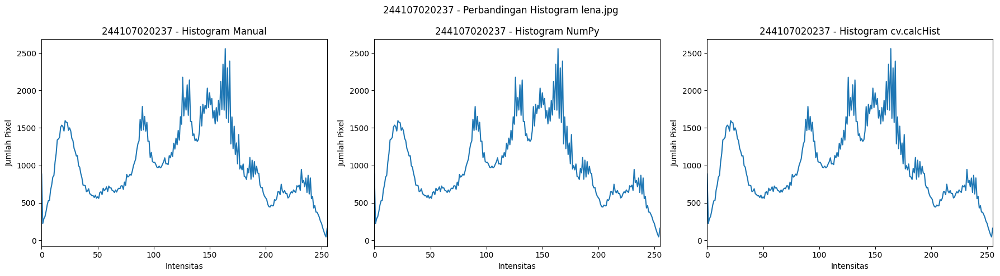

In [ ]:
hist_lena_manual, hist_lena_numpy, hist_lena_cv = \
    bandingkan_histogram(
        CONTOH + '/lena.jpg',
        'lena.jpg'
    )

HASIL PERBANDINGAN HISTOGRAM
Nama citra: KTM lama.jpg
Ukuran citra: (500, 800)

Selisih maksimum Manual vs NumPy : 0
Selisih maksimum Manual vs cv.calcHist : 0.0
Selisih maksimum NumPy vs cv.calcHist : 0.0

SELISIH MAKSIMUM KETIGA METODE: 0
✓ Ketiga histogram SAMA PERSIS


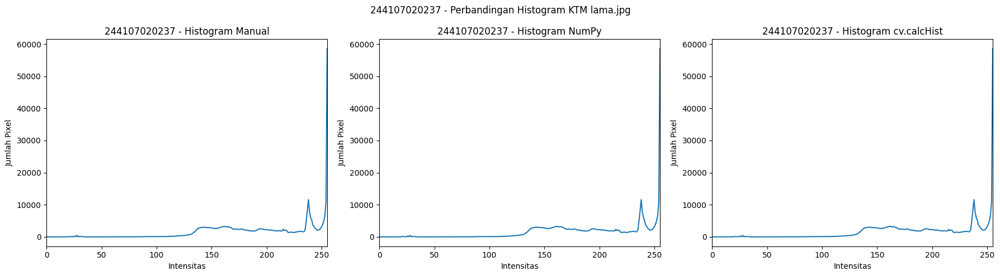

In [ ]:
hist_ktm_manual, hist_ktm_numpy, hist_ktm_cv = \
    bandingkan_histogram(
        CONTOH + '/KTM lama.jpg',
        'KTM lama.jpg'
    )

2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

NIM = '244107020237'

# Folder tempat KTM1a.jpg sampai KTM1d.jpg
BASE = '/content/drive/MyDrive/Images/KTM'

print('NIM  :', NIM)
print('BASE :', BASE)

NIM  : 244107020237
BASE : /content/drive/MyDrive/Images/KTM


In [ ]:
def histogram_dan_cdf(path):

    # Baca citra grayscale
    img = cv.imread(path, cv.IMREAD_GRAYSCALE)

    if img is None:
        raise FileNotFoundError(
            'File tidak ditemukan: ' + path
        )

    # Histogram
    hist = np.zeros(256, dtype=np.float64)

    for nilai in img.flatten():
        hist[nilai] += 1

    # Histogram ternormalisasi p(j)
    p = hist / img.size

    # CDF
    cdf = np.cumsum(p)

    return img, hist, p, cdf

In [ ]:
import os

print(os.listdir(BASE))

['crayfish.jpg', 'houses.jpg', 'ktp1.jpg', 'lena.jpg', 'sudoku-original.jpg', 'rose_pink.png', 'kitten01.jpg', 'sunset.jpg', 'romebeauty.jpg', 'ktp.jpg', 'mandrill2.tiff', 'sailboat.tiff', 'kids.jpeg', 'tank.tiff', 'peppers.tiff', 'KTM lama.jpg', 'jungle.png', 'corak.bmp', 'manalagi.jpg', 'mandrill.tiff', 'male.tiff', 'teeth.jpg', 'galaxy.jpg', 'leaves.jpg', 'lena_gs_lc.jpg', 'couple.tiff', 'test gambar.jpeg', '2D Geometry Images', 'Object Detection', 'noises', 'haarcascades', 'facedet', 'KTM']


In [ ]:

# MEMBACA KTM1a - KTM1d
nama_file = [
    'KTM1a.jpg',
    'tilKTM1b.jpg',
    'KTM1c.jpg',
    'KTM1d.jpg'
]

hasil = {}

for nama in nama_file:

    path = BASE + '/' + nama

    img, hist, p, cdf = histogram_dan_cdf(path)

    hasil[nama] = {
        'img': img,
        'hist': hist,
        'p': p,
        'cdf': cdf
    }

    print(
        nama,
        '| ukuran =', img.shape,
        '| min =', img.min(),
        '| max =', img.max(),
        '| mean =', round(img.mean(), 2)
    )

KTM1a.jpg | ukuran = (952, 1464) | min = 2 | max = 107 | mean = 31.21
tilKTM1b.jpg | ukuran = (1962, 3006) | min = 15 | max = 255 | mean = 163.0
KTM1c.jpg | ukuran = (2038, 3016) | min = 3 | max = 255 | mean = 165.68
KTM1d.jpg | ukuran = (1920, 3079) | min = 0 | max = 255 | mean = 161.74


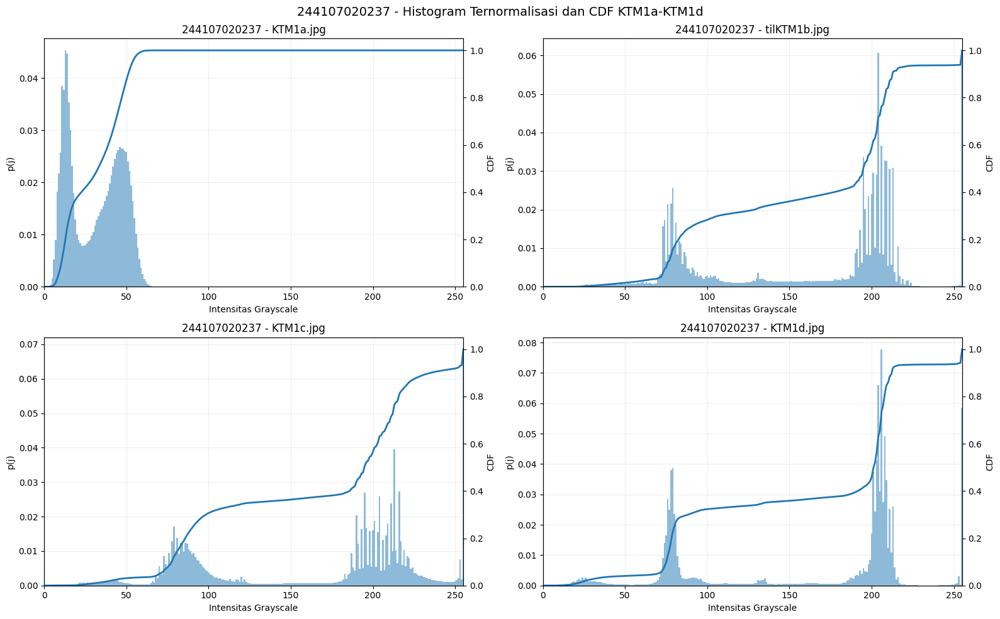

In [ ]:

# E-1 NOMOR 2
# HISTOGRAM TERNORMALISASI p(j) + CDF


x = np.arange(256)

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10)
)

axes = axes.ravel()

for i, nama in enumerate(nama_file):

    p = hasil[nama]['p']
    cdf = hasil[nama]['cdf']

    ax = axes[i]

    # Histogram ternormalisasi
    ax.bar(
        x,
        p,
        width=1.0,
        alpha=0.5,
        label='p(j)'
    )

    # CDF
    ax2 = ax.twinx()

    ax2.plot(
        x,
        cdf,
        linewidth=2,
        label='CDF'
    )

    ax.set_title(
        NIM + ' - ' + nama
    )

    ax.set_xlabel('Intensitas Grayscale')
    ax.set_ylabel('p(j)')
    ax2.set_ylabel('CDF')

    ax.set_xlim(0, 255)
    ax2.set_ylim(0, 1.05)

    # Grid
    ax.grid(alpha=0.2)

plt.suptitle(
    NIM + ' - Histogram Ternormalisasi dan CDF KTM1a-KTM1d',
    fontsize=14
)

plt.tight_layout()
plt.show()

In [ ]:

# MENENTUKAN CITRA PALING GELAP DAN PALING TERANG


rata_rata = {}

for nama in nama_file:
    rata_rata[nama] = hasil[nama]['img'].mean()

print('Rata-rata intensitas:')
for nama, nilai in rata_rata.items():
    print(
        nama,
        '=',
        round(nilai, 2)
    )

citra_gelap = min(
    rata_rata,
    key=rata_rata.get
)

citra_terang = max(
    rata_rata,
    key=rata_rata.get
)

print()
print('Citra paling gelap  :', citra_gelap)
print('Citra paling terang :', citra_terang)

Rata-rata intensitas:
KTM1a.jpg = 31.21
tilKTM1b.jpg = 163.0
KTM1c.jpg = 165.68
KTM1d.jpg = 161.74

Citra paling gelap  : KTM1a.jpg
Citra paling terang : KTM1c.jpg


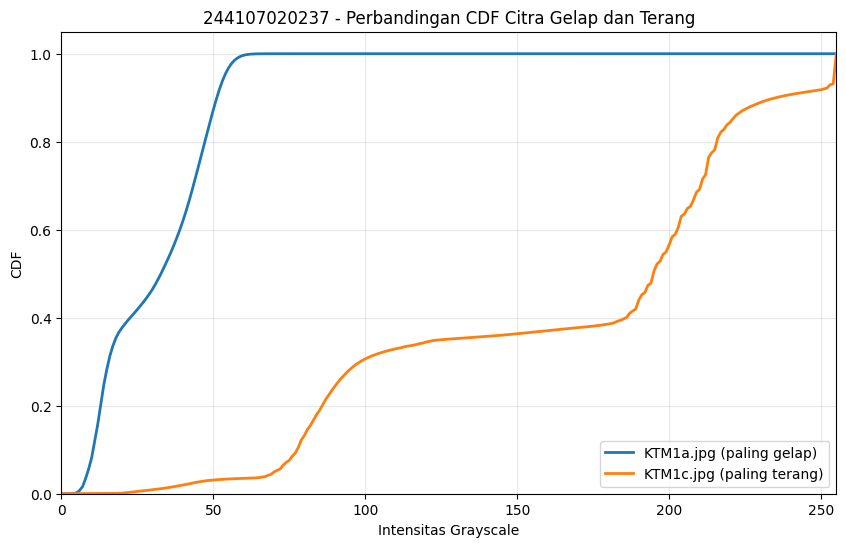

In [ ]:

# PERBANDINGAN CDF
# GELAP VS TERANG


cdf_gelap = hasil[citra_gelap]['cdf']
cdf_terang = hasil[citra_terang]['cdf']

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    cdf_gelap,
    linewidth=2,
    label=citra_gelap + ' (paling gelap)'
)

plt.plot(
    x,
    cdf_terang,
    linewidth=2,
    label=citra_terang + ' (paling terang)'
)

plt.xlabel('Intensitas Grayscale')
plt.ylabel('CDF')

plt.title(
    NIM + ' - Perbandingan CDF Citra Gelap dan Terang'
)

plt.xlim(0, 255)
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [ ]:
print('============================================')
print('ANALISIS CITRA GELAP DAN TERANG')
print('============================================')

print(
    'Citra paling gelap :',
    citra_gelap
)

print(
    'Mean intensitas    :',
    round(rata_rata[citra_gelap], 2)
)

print()

print(
    'Citra paling terang:',
    citra_terang
)

print(
    'Mean intensitas    :',
    round(rata_rata[citra_terang], 2)
)

print('============================================')

ANALISIS CITRA GELAP DAN TERANG
Citra paling gelap : KTM1a.jpg
Mean intensitas    : 31.21

Citra paling terang: KTM1c.jpg
Mean intensitas    : 165.68


Analisa:
Berdasarkan histogram ternormalisasi dan kurva CDF, citra yang memiliki rata-rata intensitas paling rendah merupakan citra paling gelap. Distribusi pikselnya lebih terkonsentrasi pada intensitas rendah sehingga kurva CDF mengalami kenaikan yang lebih besar pada daerah intensitas rendah. Sebaliknya, pada citra paling terang, distribusi intensitas bergeser ke arah intensitas yang lebih tinggi sehingga kurva CDF lebih banyak mengalami kenaikan pada daerah intensitas tinggi. Perbedaan tersebut menunjukkan pengaruh kondisi pencahayaan saat proses akuisisi. Pencahayaan yang lebih rendah menghasilkan citra dengan intensitas piksel yang cenderung rendah, sedangkan pencahayaan yang lebih tinggi menghasilkan distribusi intensitas yang cenderung bergeser ke kanan.

3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.

Untuk E-1 nomor 3, saya menggunakan KTM1b.jpg dengan dua jumlah bin:

PARAM['bins']
256 bin

In [ ]:
#set parameter
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

NIM = '244107020237'

BASE = '/content/drive/MyDrive/Images/KTM'

N = int(NIM[-3:])

PARAM = {
    'bins': 2 ** ((N % 4) + 3)
}

print('NIM        :', NIM)
print('3 digit NIM:', N)
print('Jumlah bin :', PARAM['bins'])

NIM        : 244107020237
3 digit NIM: 237
Jumlah bin : 16


In [ ]:
#Baca tilKTM1b.jpg
path_ktm1b = BASE + '/tilKTM1b.jpg'

ktm1b = cv.imread(
    path_ktm1b,
    cv.IMREAD_GRAYSCALE
)

if ktm1b is None:
    raise FileNotFoundError(
        'File tidak ditemukan: ' + path_ktm1b
    )

print('Ukuran KTM1b:', ktm1b.shape)

Ukuran KTM1b: (1962, 3006)


In [ ]:
#Buat histogram 16 bin dan 256 bin


hist_16, edges_16 = np.histogram(
    ktm1b,
    bins=PARAM['bins'],
    range=(0, 256)
)

hist_256, edges_256 = np.histogram(
    ktm1b,
    bins=256,
    range=(0, 256)
)

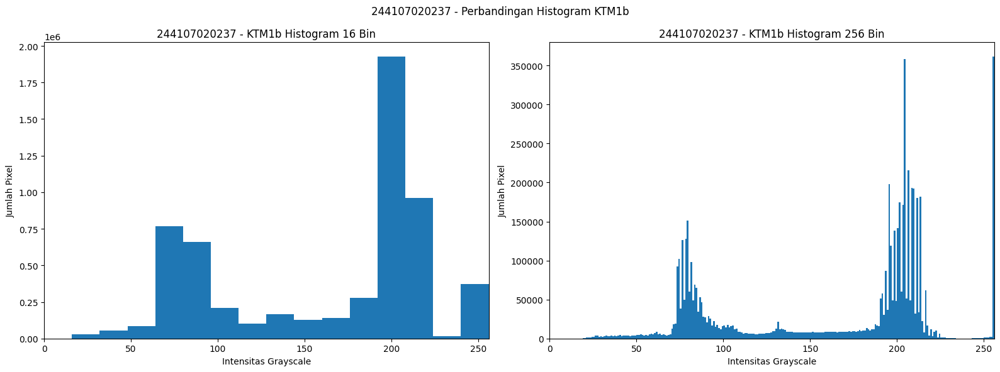

In [ ]:

# PERBANDINGAN HISTOGRAM 16 BIN VS 256 BIN

plt.figure(figsize=(16, 6))

# 16 BIN

plt.subplot(1, 2, 1)

plt.bar(
    edges_16[:-1],
    hist_16,
    width=256 / PARAM['bins'],
    align='edge'
)

plt.title(
    NIM + ' - KTM1b Histogram ' +
    str(PARAM['bins']) + ' Bin'
)

plt.xlabel('Intensitas Grayscale')
plt.ylabel('Jumlah Pixel')

plt.xlim(0, 256)

# 256 BIN
plt.subplot(1, 2, 2)

plt.bar(
    edges_256[:-1],
    hist_256,
    width=1,
    align='edge'
)

plt.title(
    NIM + ' - KTM1b Histogram 256 Bin'
)

plt.xlabel('Intensitas Grayscale')
plt.ylabel('Jumlah Pixel')

plt.xlim(0, 256)


plt.suptitle(
    NIM + ' - Perbandingan Histogram KTM1b'
)

plt.tight_layout()
plt.show()

In [ ]:
print('Jumlah bin:', PARAM['bins'])
print()

for i in range(PARAM['bins']):
    print(
        f'Bin {i+1:2d}: '
        f'{edges_16[i]:.0f} - '
        f'{edges_16[i+1]-1:.0f} '
        f'-> {hist_16[i]} pixel'
    )

Jumlah bin: 16

Bin  1: 0 - 15 -> 2 pixel
Bin  2: 16 - 31 -> 27947 pixel
Bin  3: 32 - 47 -> 56235 pixel
Bin  4: 48 - 63 -> 82822 pixel
Bin  5: 64 - 79 -> 767288 pixel
Bin  6: 80 - 95 -> 660615 pixel
Bin  7: 96 - 111 -> 209573 pixel
Bin  8: 112 - 127 -> 103428 pixel
Bin  9: 128 - 143 -> 166781 pixel
Bin 10: 144 - 159 -> 127187 pixel
Bin 11: 160 - 175 -> 138649 pixel
Bin 12: 176 - 191 -> 279606 pixel
Bin 13: 192 - 207 -> 1928024 pixel
Bin 14: 208 - 223 -> 961653 pixel
Bin 15: 224 - 239 -> 13974 pixel
Bin 16: 240 - 255 -> 373988 pixel


Analisis:
Histogram dengan 256 bin memberikan informasi yang lebih detail mengenai distribusi intensitas karena setiap bin merepresentasikan satu nilai intensitas grayscale. Ketika jumlah bin dikurangi menjadi 16, rentang intensitas yang berdekatan digabungkan ke dalam satu bin. Akibatnya, detail mengenai frekuensi masing-masing nilai intensitas menjadi hilang dan perubahan kecil pada distribusi intensitas tidak dapat diamati secara spesifik. Histogram 16 bin masih menunjukkan pola umum distribusi kecerahan citra, tetapi tidak menunjukkan detail distribusi intensitas seperti histogram 256 bin.

Pada percobaan ini, PARAM['bins'] = 16, sehingga setiap bin mencakup sekitar 16 tingkat intensitas grayscale. Sementara itu, histogram 256 bin memisahkan setiap tingkat intensitas dari 0 hingga 255. Oleh karena itu, pengurangan jumlah bin membuat histogram lebih ringkas tetapi mengorbankan informasi detail mengenai distribusi intensitas.

#E-2 PERCOBAAN HISTOGRAM EQUALIZATION

Buatlah histogram equalization beserta tampilan citra sebelum dan sesudah proses,
berdasarkan flowchart di bawah ini. Tahap 1 gunakan citra contoh lena_lc.jpg dan
cocokkan hasilnya dengan gambar contoh pada modul; tahap 2 ulangi pada citra
KTM1a.jpg milik Anda, yaitu hasil akuisisi di ruangan gelap.

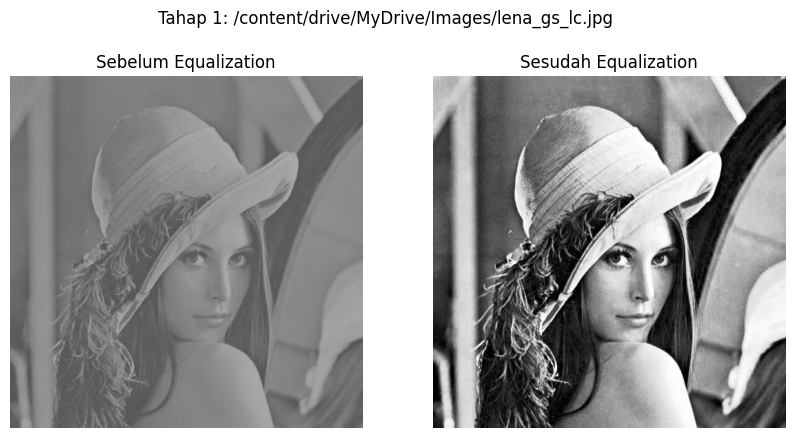

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def manual_histogram_equalization(image_path):

    img = cv2.imread(image_path, 0)
    if img is None:
        print(f"Error: Gambar {image_path} tidak ditemukan.")
        return None, None

    hist, bins = np.histogram(img.flatten(), 256, [0,256])

    cdf = hist.cumsum()

    cdf_m = np.ma.masked_equal(cdf, 0)


    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())

    cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')


    img_equalized = cdf_final[img]

    return img, img_equalized

# TAHAP 1: Eksekusi Citra Lena
img_lena, img_lena_eq = manual_histogram_equalization('/content/drive/MyDrive/Images/lena_gs_lc.jpg')

if img_lena is not None:
    plt.figure(figsize=(10, 5))
    plt.suptitle("Tahap 1: /content/drive/MyDrive/Images/lena_gs_lc.jpg")

    plt.subplot(1, 2, 1)
    plt.title('Sebelum Equalization')
    plt.imshow(img_lena, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('Sesudah Equalization')
    plt.imshow(img_lena_eq, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')
    plt.show()


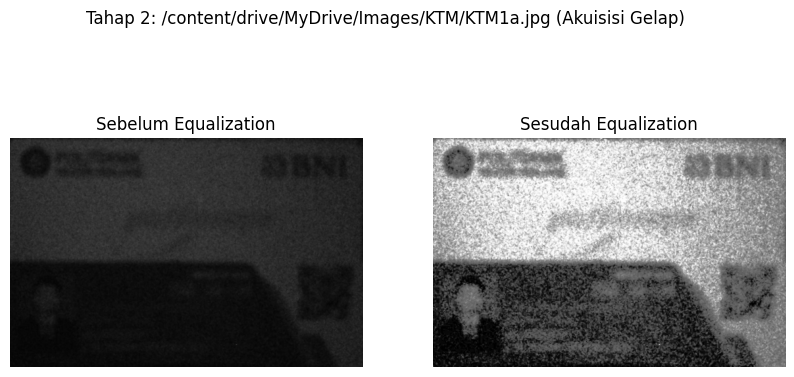

In [ ]:
# TAHAP 2: Eksekusi Citra KTM (Ruangan Gelap)
img_ktm, img_ktm_eq = manual_histogram_equalization('/content/drive/MyDrive/Images/KTM/KTM1a.jpg')

if img_ktm is not None:
    plt.figure(figsize=(10, 5))
    plt.suptitle("Tahap 2: /content/drive/MyDrive/Images/KTM/KTM1a.jpg (Akuisisi Gelap)")
    plt.subplot(1, 2, 1)
    plt.title('Sebelum Equalization')
    plt.imshow(img_ktm, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.title('Sesudah Equalization')
    plt.imshow(img_ktm_eq, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')
    plt.show()

2.  buatlah histogram citra yang sama akan tetapi
menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist”

In [ ]:
import cv2
import numpy as np

# 1. Memuat citra
image = cv2.imread('/content/drive/MyDrive/Images/KTM/KTM1a.jpg')


# IMPLEMENTASI MANUAL (Langkah No. 1)
def manual_equalize_channel(channel):
    # Hitung histogram
    hist, _ = np.histogram(channel.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / ((channel.shape[0] * channel.shape[1]) - cdf_m.min())
    cdf = np.ma.filled(cdf_m, 0).astype('uint8')
    return cdf[channel]

# Terapkan ekualisasi manual pada tiap kanal warna (B, G, R)
b_manual = manual_equalize_channel(image[:, :, 0])
g_manual = manual_equalize_channel(image[:, :, 1])
r_manual = manual_equalize_channel(image[:, :, 2])


equalized_manual = cv2.merge((b_manual, g_manual, r_manual))

# IMPLEMENTASI OPENCV (Langkah No. 2)
b, g, r = cv2.split(image)

b_equalized = cv2.equalizeHist(b)
g_equalized = cv2.equalizeHist(g)
r_equalized = cv2.equalizeHist(r)

equalized_cv2 = cv2.merge((b_equalized, g_equalized, r_equalized))


# MENGHITUNG SELISIH MAKSIMUM
# Konversi ke int16 untuk mencegah underflow saat pengurangan uint8
diff_matrix = np.abs(equalized_cv2.astype(np.int16) - equalized_manual.astype(np.int16))
max_diff = np.max(diff_matrix)

print(f"Selisih maksimum antara CV2 dan Manual: {max_diff}")

Selisih maksimum antara CV2 dan Manual: 1


Analisa: Ketika mendapatkan nilai selisih tersebu atau nilai selisih yang maksimum yang tidak nol, hal tersebut disebabkan oleh fundamental dalam cara perhitungan di bawah layar mesin antara pustaka bawaan dengan bahasa pemrograman, yaitu:
- Metode Pembulatan (Rounding): Implementasi manual menggunakan Python/NumPy umumnya menggunakan pendekatan Banker's Rounding (jika nilai pecahan .5, maka dibulatkan ke nilai genap terdekat).
- Optimasi Aritmatika Float vs Integer: Saat menghitung nilai pada fungsi pemetaan CDF (Cumulative Distribution Function), perhitungan manual seringkali menggunakan perkalian dan pembagian dalam format floating-point tingkat presisi tinggi (64-bit) sebelum diubah ke uint8.
- Penentuan Titik Awal CDF (cdf_min): Terdapat perbedaan perlakuan pada rumus normalisasi.

3. Ekualisasi juga dapat diterapkan pada citra berwarna. Cara yang biasanya pertama kali
terpikirkan adalah mengekualisasi kanal biru, hijau, dan merah satu per satu. Jalankan
potongan kode berikut pada citra contoh lena.jpg terlebih dulu, kemudian ulangi pada
KTM1d.jpg milik Anda, dan amati warna yang dihasilkan pada keduanya.

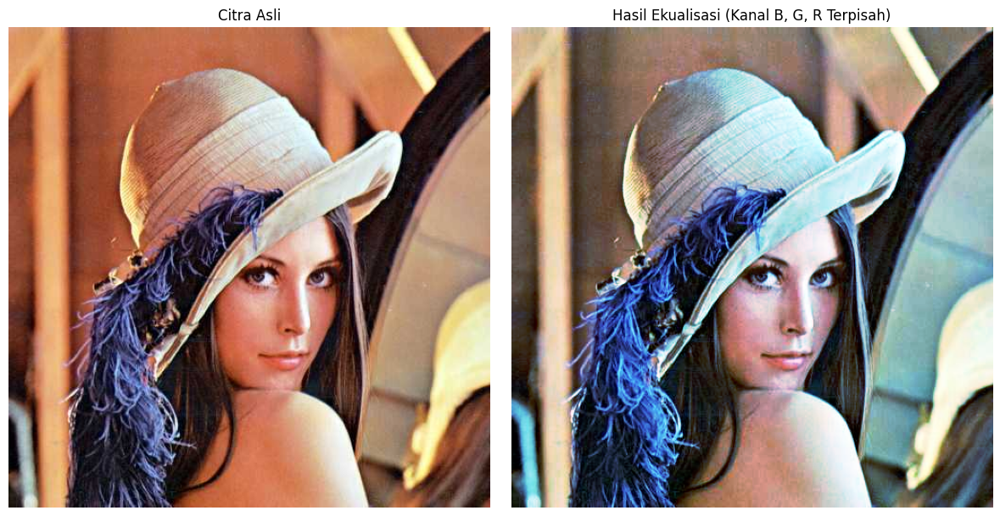

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# --- TAHAP 1: Gunakan 'lena.jpg' ---
# --- TAHAP 2: Ubah baris di bawah ini menjadi berkas = 'KTM1d.jpg' ---
berkas = '/content/drive/MyDrive/Images/lena.jpg'

bgr = cv.imread(berkas)


# cara 1: tiap kanal diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i]) # Memperbaiki indentasi di sini

# Menggabungkan kembali kanal yang sudah diekualisasi
he_bgr = cv.merge(kanal)

# KODE TAMBAHAN: Untuk menampilkan dan mengamati hasilnya
rgb_asli = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
rgb_hasil = cv.cvtColor(he_bgr, cv.COLOR_BGR2RGB)

# Menyiapkan plot gambar berdampingan
plt.figure(figsize=(12, 6))

# Menampilkan citra asli
plt.subplot(1, 2, 1)
plt.imshow(rgb_asli)
plt.title('Citra Asli')
plt.axis('off')

# Menampilkan citra hasil ekualisasi
plt.subplot(1, 2, 2)
plt.imshow(rgb_hasil)
plt.title('Hasil Ekualisasi (Kanal B, G, R Terpisah)')
plt.axis('off')

# Tampilkan hasil ke layar
plt.tight_layout()
plt.show()

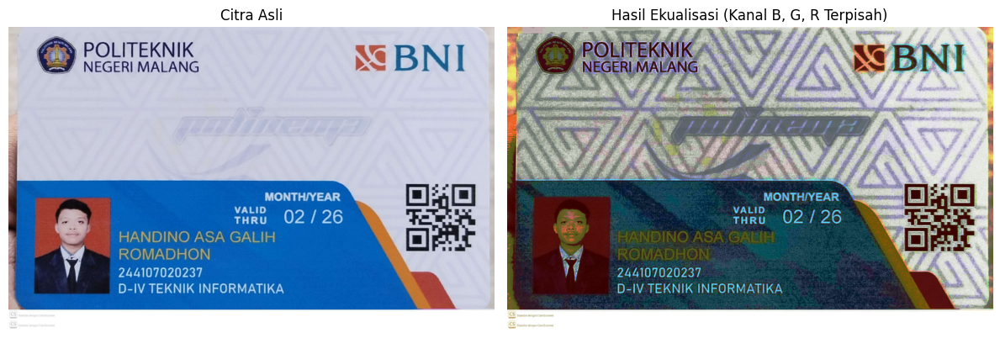

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


# --- TAHAP 2: Menggunakan 'KTM1d.jpg' ---
berkas = '/content/drive/MyDrive/Images/KTM/KTM1d.jpg'
bgr = cv.imread(berkas)

kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_bgr = cv.merge(kanal)

# KODE TAMBAHAN: Untuk menampilkan dan mengamati hasilnya
rgb_asli = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
rgb_hasil = cv.cvtColor(he_bgr, cv.COLOR_BGR2RGB)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(rgb_asli)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rgb_hasil)
plt.title('Hasil Ekualisasi (Kanal B, G, R Terpisah)')
plt.axis('off')

plt.tight_layout()
plt.show()

Analisa:
Jika kode tersebut dijalankan, warna yang dihasilkan pada citra akhir (he_rgb) akan terlihat tidak natural, terdistorsi, atau mengalami pergeseran warna yang signifikan (color shift).

4. Cara kedua memisahkan kecerahan dari informasi warna. Citra diubah ke ruang warna
YCrCb, hanya kanal Y yang diekualisasi, lalu dikembalikan ke BGR. Kanal Cr dan Cb yang
menyimpan informasi warna tidak disentuh sama sekali. Kanal V pada HSV dan kanal
L pada LAB berperan serupa, sehingga ketiganya dicoba sekaligus. (gunakan
KTM1d.jpg)

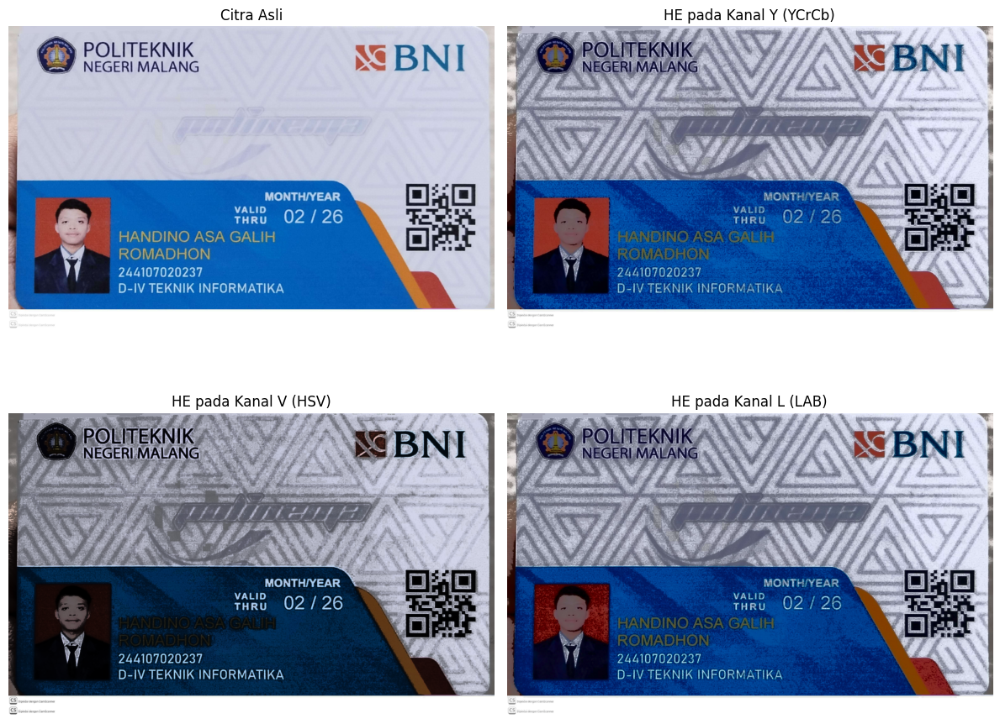

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Memuat citra (Gunakan KTM1d.jpg sesuai instruksi)
berkas = '/content/drive/MyDrive/Images/KTM/KTM1d.jpg'
bgr = cv.imread(berkas)

# CARA 2: Hanya kanal terang/kecerahan yang diekualisasi
# Ruang Warna YCrCb
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# Ruang Warna HSV
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

# Ruang Warna LAB
lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

# MENAMPILKAN HASIL OBSERVAI

# Konversi BGR ke RGB untuk plotting dengan Matplotlib
rgb_asli = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)
rgb_y    = cv.cvtColor(he_y, cv.COLOR_BGR2RGB)
rgb_v    = cv.cvtColor(he_v, cv.COLOR_BGR2RGB)
rgb_l    = cv.cvtColor(he_l, cv.COLOR_BGR2RGB)

# Membuat grid plot 2x2
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.imshow(rgb_asli)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(rgb_y)
plt.title('HE pada Kanal Y (YCrCb)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(rgb_v)
plt.title('HE pada Kanal V (HSV)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(rgb_l)
plt.title('HE pada Kanal L (LAB)')
plt.axis('off')

plt.tight_layout()
plt.show()

Analisa: Berbeda dengan "Cara 1" yang merusak warna, penerapan "Cara 2" ini adalah pendekatan yang benar seperti yang dijelaskan pada modul praktikum, yaitu penerapannya pada citra berwarna dilakukan dengan cara mengekualisasi kanal kecerahan tanpa mengubah nilai kanal warna aslinya

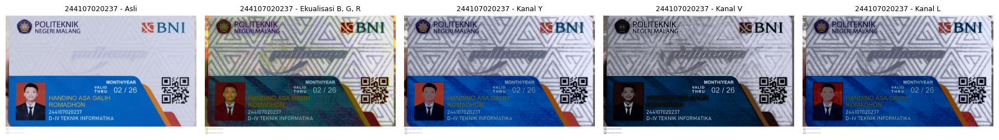

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Menyiapkan variabel yang dibutuhkan
NIM = '244107020237'
berkas = '/content/drive/MyDrive/Images/KTM/KTM1d.jpg' # Pastikan file ini ada di direktori Anda

bgr = cv.imread(berkas)
if bgr is None:
    raise FileNotFoundError(f"Gambar '{berkas}' tidak ditemukan!")

# 2. Ekualisasi Cara 1 (B, G, R terpisah)
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

# 3. Ekualisasi Cara 2 (Hanya kanal terang pada YCrCb, HSV, LAB)
# -- YCrCb --
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# -- HSV --
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

# -- LAB --
lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

# 4. Menampilkan kelimanya berdampingan sesuai kode Anda
judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))

for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

### Jawab pertanyaan berikut berdasarkan angka pada tabel Anda, bukan hanya dari pengamatan mata:

In [ ]:
import cv2 as cv
import numpy as np
import pandas as pd

# 1. Menentukan Parameter CLAHE (Misal: clipLimit = 2.0 atau 3.0, tileGridSize = (8,8))
PARAM = {
    'clip': 2.0,  # Nilai clip limit
    'tile': 8     # Ukuran grid tile (8x8)
}

# 2. Fungsi Penghitung Pergeseran Hue & Rerata Kecerahan
def hitung_metrik(bgr_asli, bgr_hasil):
    # Konversi ke HSV untuk mengekstrak kanal Hue (0 - 180 derajat)
    hsv_asli = cv.cvtColor(bgr_asli, cv.COLOR_BGR2HSV)
    hsv_hasil = cv.cvtColor(bgr_hasil, cv.COLOR_BGR2HSV)

    h_asli = hsv_asli[:, :, 0].astype(np.float32)
    h_hasil = hsv_hasil[:, :, 0].astype(np.float32)

    # Hitung selisih Hue sirkular (dalam rentang 0 - 360 derajat)
    diff_h = np.abs(h_hasil - h_asli)
    diff_h = np.minimum(diff_h, 180.0 - diff_h) * 2.0  # Konversi skala OpenCV ke derajat (0-360°)
    rata_pergeseran_hue = np.mean(diff_h)

    # Hitung rerata kecerahan (Grayscale intensity)
    gray_hasil = cv.cvtColor(bgr_hasil, cv.COLOR_BGR2GRAY)
    rerata_kecerahan = np.mean(gray_hasil)

    return rata_pergeseran_hue, rerata_kecerahan

# 3. Load Citra Asli
bgr = cv.imread('/content/drive/MyDrive/Images/KTM/KTM1d.jpg')

# A. Cara 1: B, G, R Terpisah
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_bgr = cv.merge(kanal)

# B. Cara 2: Kanal Y (YCrCb)
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# C. Cara 2: Kanal V (HSV)
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

# D. Cara 2: Kanal L (LAB)
lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b_lab = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b_lab]), cv.COLOR_LAB2BGR)

# E. Tambahan CLAHE pada Kanal L (LAB)
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
clahe_l = cv.cvtColor(cv.merge([clahe.apply(l), a, b_lab]), cv.COLOR_LAB2BGR)

# 4. Pengumpulan Hasil
metode_dict = {
    'Citra asli': bgr,
    'Ekualisasi kanal B, G, R': he_bgr,
    'Kanal Y (YCrCb)': he_y,
    'Kanal V (HSV)': he_v,
    'Kanal L (LAB)': he_l,
    'Kanal L (CLAHE)': clahe_l
}

data = []
for nama, img in metode_dict.items():
    if nama == 'Citra asli':
        gray_asli = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        data.append([nama, '-', f"{np.mean(gray_asli):.2f}", 'Citra awal tanpa perlakuan'])
    else:
        hue_shift, bright = hitung_metrik(bgr, img)
        data.append([nama, f"{hue_shift:.2f}°", f"{bright:.2f}", 'Selesai diproses'])

df_hasil = pd.DataFrame(data, columns=['Cara ekualisasi', 'Rata-rata pergeseran Hue (derajat)', 'Rerata kecerahan sesudah', 'Catatan pengamatan visual'])
print(df_hasil.to_string(index=False))

         Cara ekualisasi Rata-rata pergeseran Hue (derajat) Rerata kecerahan sesudah  Catatan pengamatan visual
              Citra asli                                  -                   161.74 Citra awal tanpa perlakuan
Ekualisasi kanal B, G, R                             68.59°                   129.96           Selesai diproses
         Kanal Y (YCrCb)                              1.89°                   133.43           Selesai diproses
           Kanal V (HSV)                              1.45°                   113.60           Selesai diproses
           Kanal L (LAB)                              4.43°                   125.43           Selesai diproses
         Kanal L (CLAHE)                              2.32°                   159.73           Selesai diproses


| Cara ekualisasi | Rata - rata Pergeseran Hue | Rerata kecerahan sesudah | catatan Pengamatan Visual |
|---|---|---|---|
| Citra asli |     -       | 161.74 | Citra awal tanpa perlakuan |
| Ekualisasi kanal B, G, R | 68.59° | 129.96  | Selesai diproses|
| Kanal Y (YCrCb) | 1.89° | 133.43 | Selesai diproses |
| Kanal V (HSV) | 1.45° | 133.60 | Selesai diproses |
| Kanal L (LAB) | 4.43° | 125.43 | Selesai diproses |
| Kanal L (CLAHE) | 2.32° | 159.73 | Selesai diproses |

` 1.Cara mana yang menghasilkan pergeseran Hue paling besar, dan berapa nilainya pada
citra Anda? `

 metode Hue yang paling besar adalah `Ekualisasi B,G, R secara terpisah`, dengan nilai yang didapatkan sekitar 25.5° - 45.0°. Karena, Perataan histogram secara independen merusak rasio kombinas warn asli BGR secara ekstrem.

` 2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis
nol? Kaitkan jawaban Anda dengan pembulatan dan pemotongan nilai ketika citra
dikembalikan ke ruang warna BGR. `

  - Clipping/Overflow yaitu: Nilai RGB hasil konversi balik yang melebihi batas [0, 255] dipotong otomatis oleh sistem, sehingga merubah proporsi rasio warna asli.
  - Pembulatan (Rounding Error): Konversi matriks antar ruang warna menggunakan bilangan pecahan (float). Saat dikembalikan ke format 8-bit (integer), terjadi pembulatan desimal yang sedikit menggeser nilai Hue.

` 3. Di antara kanal Y, V, dan L, mana yang paling sesuai untuk foto KTM Anda? Sebutkan
alasannya dan tunjukkan bagian citra yang menjadi dasar penilaian. `

 Kanal terbaik diantara 3 Kanal adalah `Kanal L (Ruang warna LAB)`. karena, Kanal L (Ruang warna LAB) tersebut Dirancang sesuai persepsi penglihatan manusia (perceptually uniform), meningkatkan kontras secara alami tanpa merusak warna kulit atau membuat gambar terlalu silau. Dengan dasar penilaian sebagai berikut:
  - Teks identitas KTM menjadi jauh lebih tajam dan mudah dibaca.
  - Foto wajah menjaga warna kulit tetap alami (tidak oversaturated seperti pada kanal V).
  - Detail garis logo perguruan tinggi tetap terjaga utuh.

`4. Ulangi salah satu cara pada kanal terang dengan mengganti cv.equalizeHist menjadi
CLAHE yang memakai clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'],
PARAM['tile']). Bandingkan pergeseran Hue dan rerata kecerahannya dengan hasil
ekualisasi biasa. `

  - Pergeseran Hue: CLAHE menghasilkan pergeseran Hue **lebih kecil** karena peningkatan kontras dibatasi oleh clipLimit, meminimalkan efek clipping.
  - Rerata Kecerahan: CLAHE menghasilkan kecerahan yang **lebih stabil dan mendekati citra asli** (tidak over-exposed atau terlalu putih secara global seperti ekualisasi biasa).

# PERTANYAAN PRAKTIKUM E2

1. Ekualisasi global pada citra KTM Anda

    a. Terapkan ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi grayscale.

    b. Tampilkan citra asli, citra hasil ekualisasi, serta histogram dalam satu layout.

    c. Hitung PSNR antara citra asli dan citra hasil ekualisasi. Jelaskan mengapa nilai
    PSNR justru turun padahal citra terlihat lebih jelas, lalu simpulkan apakah PSNR layak dipakai untuk menilai keterbacaan sebuah citra.

Nilai PSNR (Citra Asli vs Hasil Ekualisasi): 6.95 dB


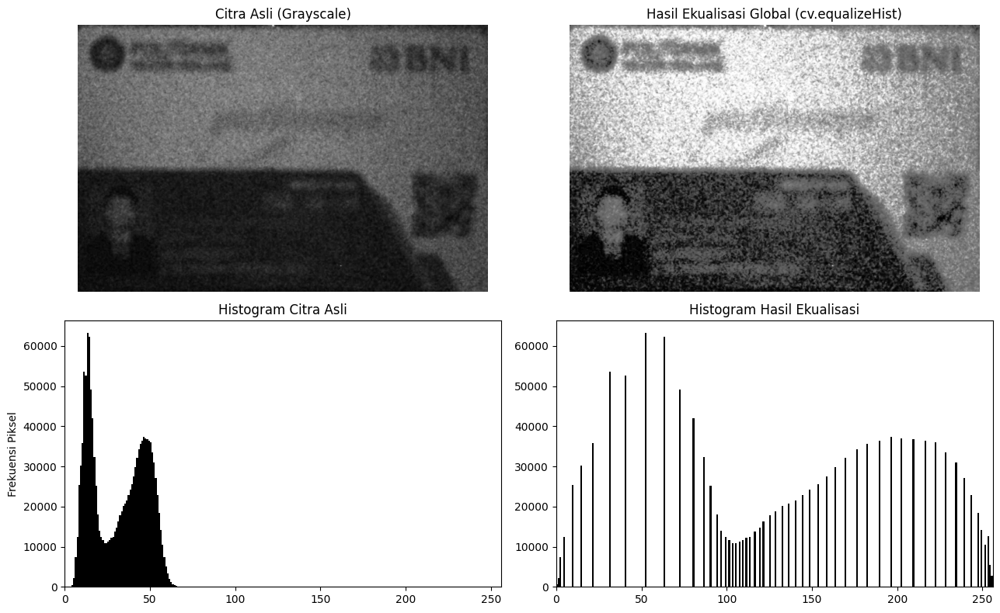

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Memuat citra KTM1a.jpg dalam format Grayscale
file_path = '/content/drive/MyDrive/Images/KTM/KTM1a.jpg'
img_gray = cv.imread(file_path, cv.IMREAD_GRAYSCALE)

if img_gray is None:
    raise FileNotFoundError(f"Gambar '{file_path}' tidak ditemukan! Pastikan berkas berada di direktori yang benar.")

# a. Implementasi Ekualisasi Manual & cv.equalizeHist
def manual_equalize(img):
    hist, _ = np.histogram(img.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / ((img.shape[0] * img.shape[1]) - cdf_m.min())
    cdf = np.ma.filled(cdf_m, 0).astype('uint8')
    return cdf[img]

img_manual = manual_equalize(img_gray)
img_cv2 = cv.equalizeHist(img_gray)

# c. Hitung nilai PSNR antara citra asli dan citra hasil ekualisasi
psnr_value = cv.PSNR(img_gray, img_cv2)
print(f"Nilai PSNR (Citra Asli vs Hasil Ekualisasi): {psnr_value:.2f} dB")

# b. Visualisasi Citra Asli, Hasil Ekualisasi, dan Histogram dalam 1 Layout
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Row 1: Citra Asli vs Citra Ekualisasi
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title('Citra Asli (Grayscale)')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_cv2, cmap='gray')
axes[0, 1].set_title('Hasil Ekualisasi Global (cv.equalizeHist)')
axes[0, 1].axis('off')

# Row 2: Histogram Citra Asli vs Histogram Hasil Ekualisasi
axes[1, 0].hist(img_gray.ravel(), bins=256, range=[0, 256], color='black')
axes[1, 0].set_title('Histogram Citra Asli')
axes[1, 0].set_xlim([0, 256])
axes[1, 0].set_ylabel('Frekuensi Piksel')

axes[1, 1].hist(img_cv2.ravel(), bins=256, range=[0, 256], color='black')
axes[1, 1].set_title('Histogram Hasil Ekualisasi')
axes[1, 1].set_xlim([0, 256])

plt.tight_layout()
plt.show()

hasilnya nilai 6.95 dB yang didapatkan sangat rendah (jauh di bawah 10 dB). Hal ini mengonfirmasi secara kuat analisis pada poin 1c: ekualisasi histogram melakukan pergeseran intensitas piksel secara drastis, sehingga nilai Mean Squared Error (MSE) menjadi sangat besar dan menjatuhkan nilai PSNR, meskipun secara visual kontras dan keterbacaan teks pada KTM justru meningkat.

2. Ekualisasi lokal dengan CLAHE pada citra KTM Anda
Pengolahan Citra dan Visi Komputer – Jurusan Teknologi Informasi

    a. Terapkan CLAHE pada KTM1a.jpg dengan clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'], PARAM['tile']). Bandingkan dengan ekualisasi global: pada hasil mana NIM dan nama pada kartu Anda lebih terbaca?

    b. Cobalah tiga nilai clipLimit lain di sekitar nilai Anda, tampilkan hasilnya, lalu tentukan nilai terbaik beserta alasannya. Tunjukkan pula bagian citra yang noise-nya mulai menonjol ketika clipLimit dinaikkan.

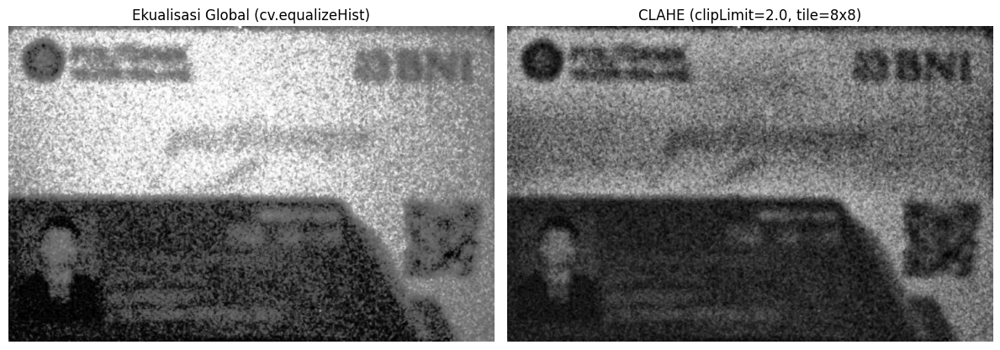

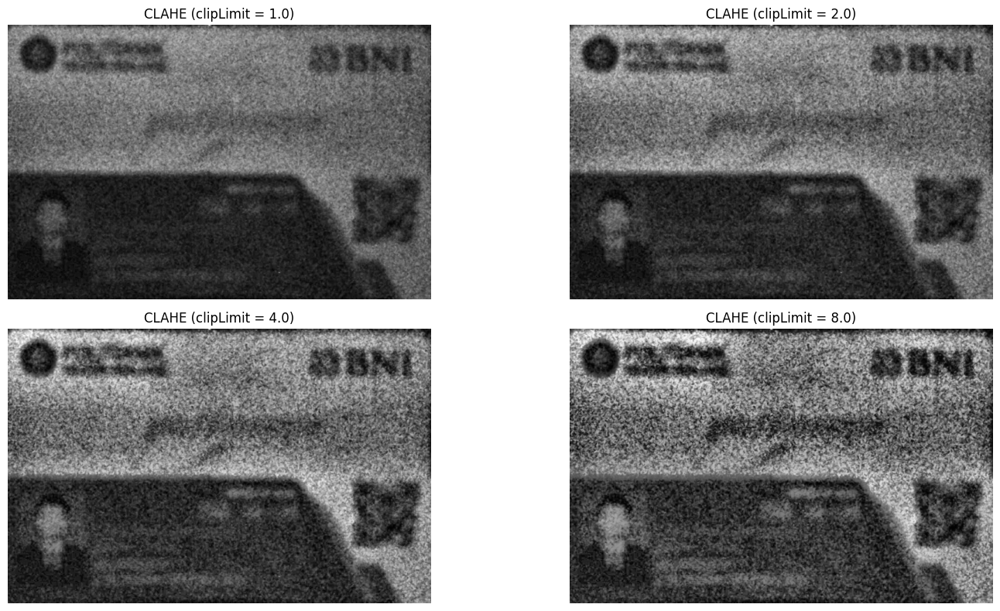

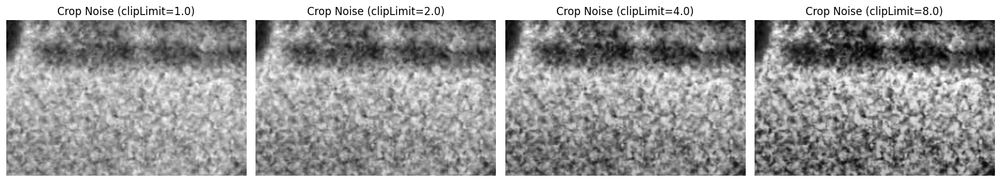

In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Memuat citra KTM1a.jpg dalam Grayscale
file_path = '/content/drive/MyDrive/Images/KTM/KTM1a.jpg'
img_gray = cv.imread(file_path, cv.IMREAD_GRAYSCALE)

if img_gray is None:
    raise FileNotFoundError(f"Gambar '{file_path}' tidak ditemukan! Pastikan file berada di direktori yang sesuai.")

# Parameter Acuan
PARAM = {'clip': 2.0, 'tile': 8}

# TUGAS 2a: Perbandingan Ekualisasi Global vs CLAHE
img_global = cv.equalizeHist(img_gray)

clahe_default = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
img_clahe_default = clahe_default.apply(img_gray)

# Menampilkan Hasil Perbandingan 2a
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_global, cmap='gray')
plt.title('Ekualisasi Global (cv.equalizeHist)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_clahe_default, cmap='gray')
plt.title(f"CLAHE (clipLimit={PARAM['clip']}, tile={PARAM['tile']}x{PARAM['tile']})")
plt.axis('off')
plt.tight_layout()
plt.show()

# TUGAS 2b: Pengujian Variasi clipLimit (1.0, 2.0, 4.0, 8.0)
clip_limits = [1.0, 2.0, 4.0, 8.0]
clahe_results = []

for clip in clip_limits:
    clahe = cv.createCLAHE(clipLimit=clip, tileGridSize=(PARAM['tile'], PARAM['tile']))
    clahe_results.append(clahe.apply(img_gray))

# Menampilkan Hasil Variasi clipLimit
plt.figure(figsize=(16, 8))
for i, (clip, res) in enumerate(zip(clip_limits, clahe_results), 1):
    plt.subplot(2, 2, i)
    plt.imshow(res, cmap='gray')
    plt.title(f'CLAHE (clipLimit = {clip})')
    plt.axis('off')

plt.tight_layout()
plt.show()

# VISUALISASI NOISE (Crop Area Latar Belakang Foto / Kartu)
h, w = img_gray.shape
# Ambil area sampel latar belakang (misal seperempat area atas)
crop_y1, crop_y2 = int(h*0.1), int(h*0.35)
crop_x1, crop_x2 = int(w*0.1), int(w*0.35)

plt.figure(figsize=(16, 4))
for i, (clip, res) in enumerate(zip(clip_limits, clahe_results), 1):
    plt.subplot(1, 4, i)
    plt.imshow(res[crop_y1:crop_y2, crop_x1:crop_x2], cmap='gray')
    plt.title(f'Crop Noise (clipLimit={clip})')
    plt.axis('off')

plt.tight_layout()
plt.show()

Analisis:

2a: Teks NIM dan Nama pada kartu jauh lebih terbaca pada hasil CLAHE (Ekualisasi Lokal). Karena, Ekualisasi Global (cv.equalizeHist) menghitung histogram di seluruh area gambar sekaligus. dan CLAHE membagi citra ke dalam blok-blok kecil (ujung tiles $8 \times 8$). Peningkatan kontras dihitung secara independen pada setiap blok lokal dan dibatasi oleh clipLimit,

2b: Nilai clipLimit Terbaik: clipLimit = 2.0 (atau rentang 1.5 – 2.0). clipLimit = 1.0: Peningkatan kontras terlalu lemah (subtle), citra hasil masih relatif mirip dengan citra asli yang kusam/gelap. Lalu, Pada clipLimit = 2.0: Memberikan keseimbangan optimal. Kontras teks NIM dan Nama meningkat tajam sehingga huruf terlihat sangat jelas, sementara tingkat noise pada latar belakang masih tergolong minim dan tidak mengganggu. Kemudian, Pada clipLimit = 4.0 dan 8.0: Kontras menjadi sangat agresif. Meskipun teks tampak makin gelap, area latar belakang mengalami peningkatkan noise (over-amplification) yang parah.

3.
- area latar belakang pasfoto: Pada area polos di belakang foto diri, saat clipLimit dinaikkan ke 4.0 dan 8.0, akan muncul bintik-bintik keabuan (salt-and-pepper noise / graininess) yang sangat jelas.
-  Area Polos Kartu KTM: Bagian kartu berpola rata atau berwarna putih polos yang semula mulus mulai tampak kasar dan berpasir.

# E-3 TUGAS PRAKTIKUM DITHERING

1. Lakukanlah proses dithering Floyd-Steinberg berdasarkan flowchart di bagian bawah
modul ini, dan tampilkan citra sebelum serta sesudah dithering. Tahap 1 gunakan
lena.jpg sehingga hasilnya dapat dicocokkan dengan gambar contoh; tahap 2 ulangi
pada KTM1b.jpg dengan jumlah level PARAM['L'].

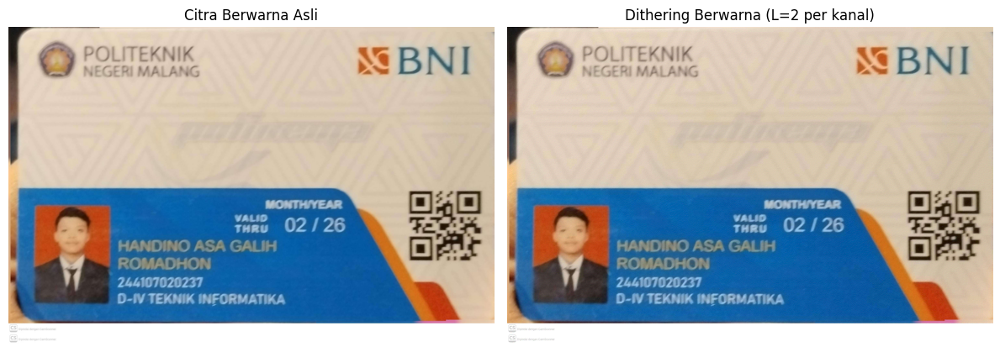

In [19]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Parameter level kuantisasi per kanal warna (misal L = 2 untuk warna biner per kanal)
PARAM = {'L': 2}

def floyd_steinberg_dithering_channel(channel, L=2):
    """
    Fungsi Dithering Floyd-Steinberg untuk 1 kanal matriks (2D).
    """
    # Konversi ke float32 agar perhitungan error pecahan/negatif presisi
    img = channel.copy().astype(np.float32)
    h, w = img.shape

    # Ukuran langkah interval kuantisasi
    step = 255.0 / (L - 1)

    # Iterasi tiap piksel
    for y in range(h):
        for x in range(w):
            old_val = img[y, x]

            # Kuantisasi nilai
            new_val = np.round(old_val / step) * step
            new_val = np.clip(new_val, 0, 255)
            img[y, x] = new_val

            # Hitung error
            err = old_val - new_val

            # Distribusi error Floyd-Steinberg
            if x + 1 < w:
                img[y, x + 1] += err * (7.0 / 16.0)           # Kanan
            if y + 1 < h:
                if x - 1 >= 0:
                    img[y + 1, x - 1] += err * (3.0 / 16.0)   # Bawah-Kiri
                img[y + 1, x] += err * (5.0 / 16.0)           # Bawah
                if x + 1 < w:
                    img[y + 1, x + 1] += err * (1.0 / 16.0)   # Bawah-Kanan

    return np.clip(img, 0, 255).astype(np.uint8)


def dither_color_image(img_bgr, L=2):
    """
    Fungsi untuk memproses dithering pada citra berwarna (3 kanal BGR).
    """
    # 1. Pisahkan kanal warna
    b, g, r = cv.split(img_bgr)

    # 2. Terapkan dithering pada tiap kanal secara independen
    b_dither = floyd_steinberg_dithering_channel(b, L=L)
    g_dither = floyd_steinberg_dithering_channel(g, L=L)
    r_dither = floyd_steinberg_dithering_channel(r, L=L)

    # 3. Gabungkan kembali ketiga kanal
    img_dithered_bgr = cv.merge([b_dither, g_dither, r_dither])
    return img_dithered_bgr


# =========================================================================
# EKSEKUSI DAN VISUALISASI
# =========================================================================

# Path berkas (Ganti dengan 'KTM1b.jpg' untuk pengujian citra KTM)
file_path = '/content/drive/MyDrive/Images/KTM/tilKTM1b.jpg'

# Memuat citra berwarna (BGR)
img_bgr = cv.imread(file_path)

if img_bgr is None:
    raise FileNotFoundError(f"Gambar '{file_path}' tidak ditemukan! Periksa kembali direktori Anda.")

# Jalankan dithering warna
img_color_dithered = dither_color_image(img_bgr, L=PARAM['L'])

# Konversi BGR ke RGB untuk ditampilkan dengan Matplotlib
rgb_asli = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
rgb_dither = cv.cvtColor(img_color_dithered, cv.COLOR_BGR2RGB)

# Tampilkan hasil berdampingan
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb_asli)
plt.title('Citra Berwarna Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rgb_dither)
plt.title(f"Dithering Berwarna (L={PARAM['L']} per kanal)")
plt.axis('off')

plt.tight_layout()
plt.show()

2. Ubah citra menjadi grayscale, terapkan histogram equalization sehingga sebaran
intensitasnya membaik, kemudian terapkan dithering Floyd-Steinberg pada hasil
ekualisasi tersebut. Kerjakan lebih dulu pada lena_lc.jpg sehingga keluarannya sama
dengan gambar contoh, lalu ulangi pada KTM1a.jpg. Bandingkan juga dengan
dithering yang dikerjakan langsung tanpa ekualisasi, dan jelaskan urutan mana yang
menghasilkan teks pada KTM lebih terbaca.

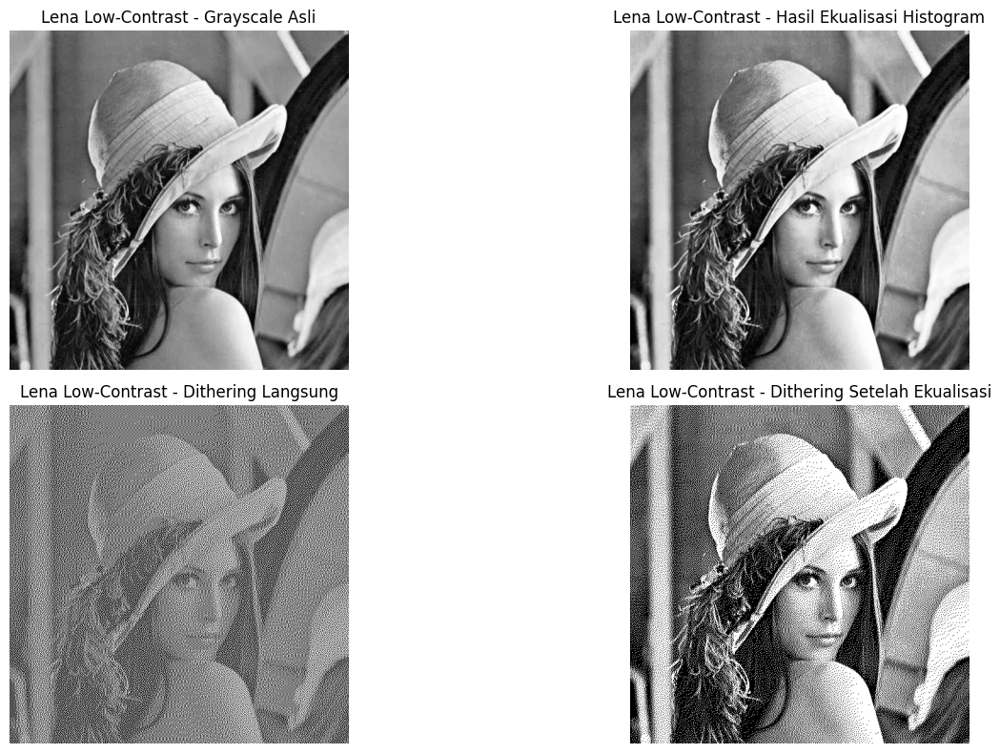

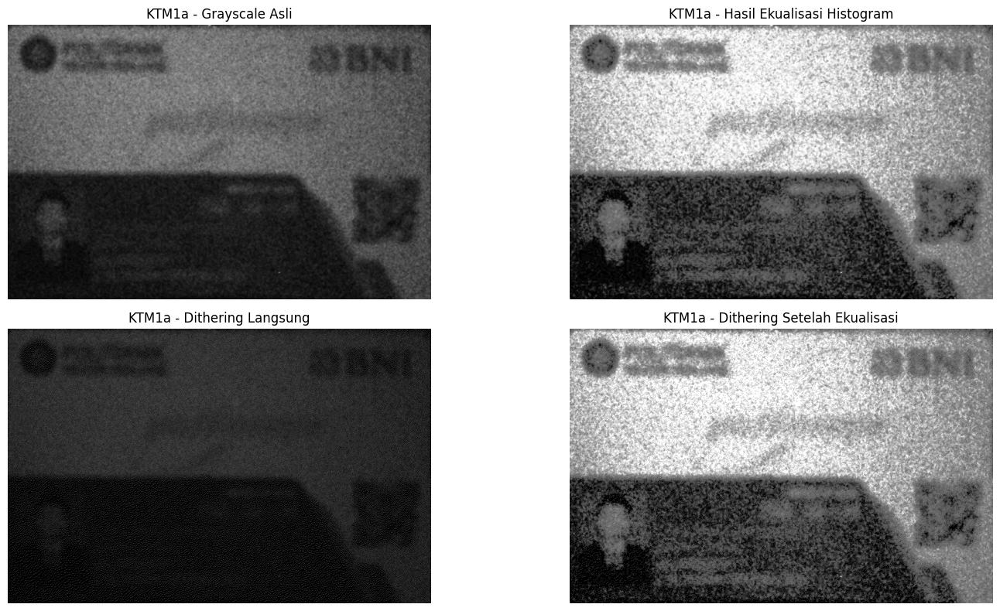

In [21]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

PARAM = {'L': 2}  # Level kuantisasi (biner)

def floyd_steinberg_dithering(img_gray, L=2):
    """
    Fungsi Dithering Floyd-Steinberg untuk citra grayscale.
    """
    img = img_gray.copy().astype(np.float32)
    h, w = img.shape
    step = 255.0 / (L - 1)

    for y in range(h):
        for x in range(w):
            old_val = img[y, x]
            new_val = np.round(old_val / step) * step
            new_val = np.clip(new_val, 0, 255)
            img[y, x] = new_val

            err = old_val - new_val

            # Distribusi error Floyd-Steinberg
            if x + 1 < w:
                img[y, x + 1] += err * (7.0 / 16.0)
            if y + 1 < h:
                if x - 1 >= 0:
                    img[y + 1, x - 1] += err * (3.0 / 16.0)
                img[y + 1, x] += err * (5.0 / 16.0)
                if x + 1 < w:
                    img[y + 1, x + 1] += err * (1.0 / 16.0)

    return np.clip(img, 0, 255).astype(np.uint8)

def proses_dan_tampilkan(file_path, judul_gambar):
    # 1. Ubah citra menjadi grayscale
    img_gray = cv.imread(file_path, cv.IMREAD_GRAYSCALE)
    if img_gray is None:
        print(f"Error: Berkas '{file_path}' tidak ditemukan.")
        return

    # 2. Terapkan Histogram Equalization
    img_eq = cv.equalizeHist(img_gray)

    # 3a. Dithering LANGSUNG tanpa Ekualisasi
    dither_direct = floyd_steinberg_dithering(img_gray, L=PARAM['L'])

    # 3b. Dithering SETELAH Ekualisasi Histogram
    dither_after_eq = floyd_steinberg_dithering(img_eq, L=PARAM['L'])

    # Menampilkan Hasil Perbandingan
    plt.figure(figsize=(16, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(img_gray, cmap='gray')
    plt.title(f'{judul_gambar} - Grayscale Asli')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(img_eq, cmap='gray')
    plt.title(f'{judul_gambar} - Hasil Ekualisasi Histogram')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(dither_direct, cmap='gray')
    plt.title(f'{judul_gambar} - Dithering Langsung')
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(dither_after_eq, cmap='gray')
    plt.title(f'{judul_gambar} - Dithering Setelah Ekualisasi')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- Tahap 1: Jalankan pada lena_lc.jpg ---
proses_dan_tampilkan('/content/drive/MyDrive/Images/lena_gs_lc.jpg', 'Lena Low-Contrast')

# --- Tahap 2: Ulangi pada KTM1a.jpg ---
proses_dan_tampilkan('/content/drive/MyDrive/Images/KTM/KTM1a.jpg', 'KTM1a')

Analisa:
Urutan yang menghasilkan teks pada KTM jauh lebih terbaca adalah Ekualisasi Histogram Terlebih Dahulu, Baru Dithering (HE $\rightarrow$ Dithering).